# Cybersecurity Threat Data Analysis

## Objective

The objective of this project is to analyze cybersecurity threat data from 2015–2024 using Python and Pandas.

## Tools Used

- Python
- Pandas
- Matplotlib
- Google Colab

## Analysis Performed

- Data Inspection and Exploration
- Attack Type Analysis
- Country-wise Analysis
- Industry-wise Analysis
- Financial Loss Analysis
- Trend Analysis

In [111]:
import pandas as pd

df = pd.read_csv('Global_Cybersecurity_Threats_2015-2024.csv')

df.head()

,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68


# 1. Data Inspection and Cleaning

In [112]:
df.isnull().sum()

,0
Country,0
Year,0
Attack Type,0
Target Industry,0
Financial Loss (in Million $),0
Number of Affected Users,0
Attack Source,0
Security Vulnerability Type,0
Defense Mechanism Used,0
Incident Resolution Time (in Hours),0


In [113]:
df.duplicated().sum()

np.int64(0)

In [114]:
df.shape

(3000, 10)

In [115]:
df.columns

Index(['Country', 'Year', 'Attack Type', 'Target Industry',
       'Financial Loss (in Million $)', 'Number of Affected Users',
       'Attack Source', 'Security Vulnerability Type',
       'Defense Mechanism Used', 'Incident Resolution Time (in Hours)'],
      dtype='object')

In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Country                              3000 non-null   object 
 1   Year                                 3000 non-null   int64  
 2   Attack Type                          3000 non-null   object 
 3   Target Industry                      3000 non-null   object 
 4   Financial Loss (in Million $)        3000 non-null   float64
 5   Number of Affected Users             3000 non-null   int64  
 6   Attack Source                        3000 non-null   object 
 7   Security Vulnerability Type          3000 non-null   object 
 8   Defense Mechanism Used               3000 non-null   object 
 9   Incident Resolution Time (in Hours)  3000 non-null   int64  
dtypes: float64(1), int64(3), object(6)
memory usage: 234.5+ KB


# 2. Attack Type Analysis

In [117]:
attack_counts = df['Attack Type'].value_counts()

attack_counts

,count
Attack Type,
DDoS,531
Phishing,529
SQL Injection,503
Ransomware,493
Malware,485
Man-in-the-Middle,459


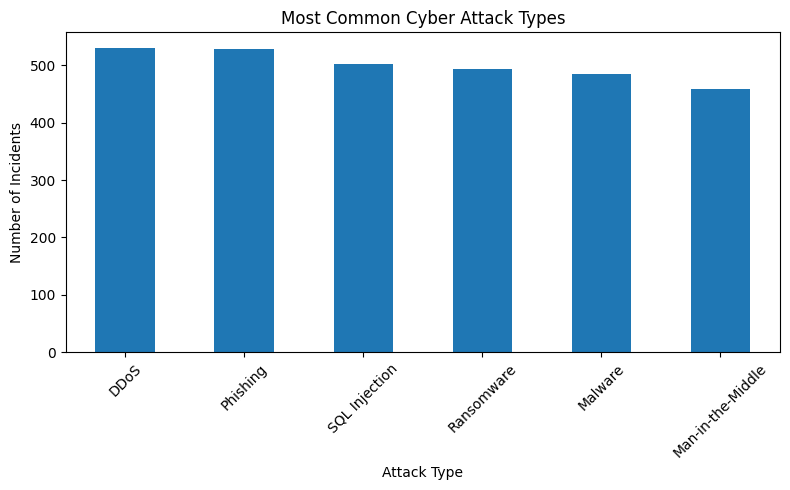

In [118]:
import matplotlib.pyplot as plt

attack_counts = df['Attack Type'].value_counts()

plt.figure(figsize=(8,5))

attack_counts.plot(kind='bar')

plt.title('Most Common Cyber Attack Types')
plt.xlabel('Attack Type')
plt.ylabel('Number of Incidents')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## Analysis & Interpretation

DDoS attacks were the most frequently recorded attack type with 531 incidents, closely followed by Phishing attacks with 529 incidents. SQL Injection and Ransomware attacks also accounted for a significant portion of the recorded threats. The relatively balanced distribution across attack categories suggests that organizations face multiple forms of cyber threats rather than a single dominant attack vector.

# 3. Country-wise Analysis

In [119]:
country_counts = df['Country'].value_counts()

country_counts

,count
Country,
UK,321
Brazil,310
India,308
Japan,305
France,305
Australia,297
Russia,295
Germany,291
USA,287


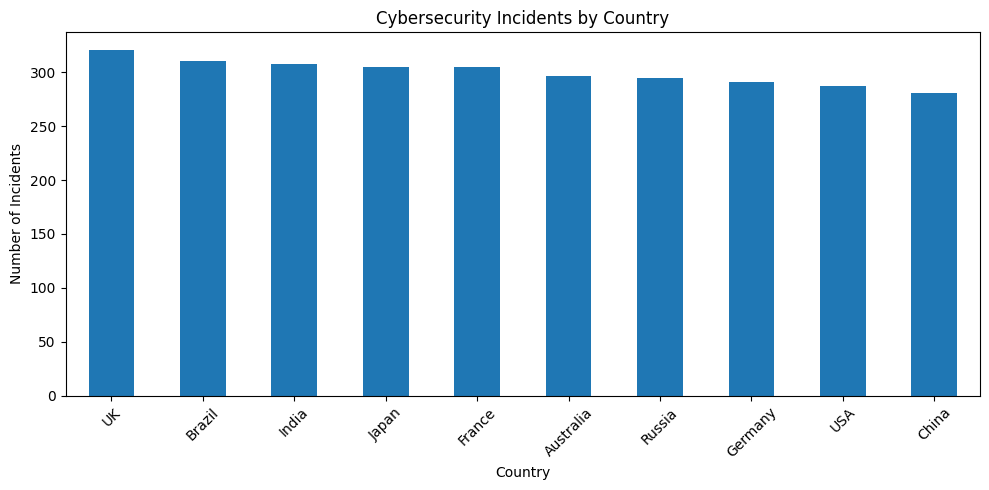

In [120]:
import matplotlib.pyplot as plt

country_counts = df['Country'].value_counts()

plt.figure(figsize=(10,5))

country_counts.plot(kind='bar')

plt.title('Cybersecurity Incidents by Country')
plt.xlabel('Country')
plt.ylabel('Number of Incidents')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## Analysis & Interpretation

The United Kingdom recorded the highest number of cybersecurity incidents (321), followed by Brazil (310) and India (308). The difference in incident counts among countries is relatively small, indicating that cyber threats are widespread and affect organizations globally rather than being concentrated in a specific region.

# 4. Industry-wise Analysis

In [121]:
industry_counts = df['Target Industry'].value_counts()

industry_counts

,count
Target Industry,
IT,478
Banking,445
Healthcare,429
Retail,423
Education,419
Government,403
Telecommunications,403


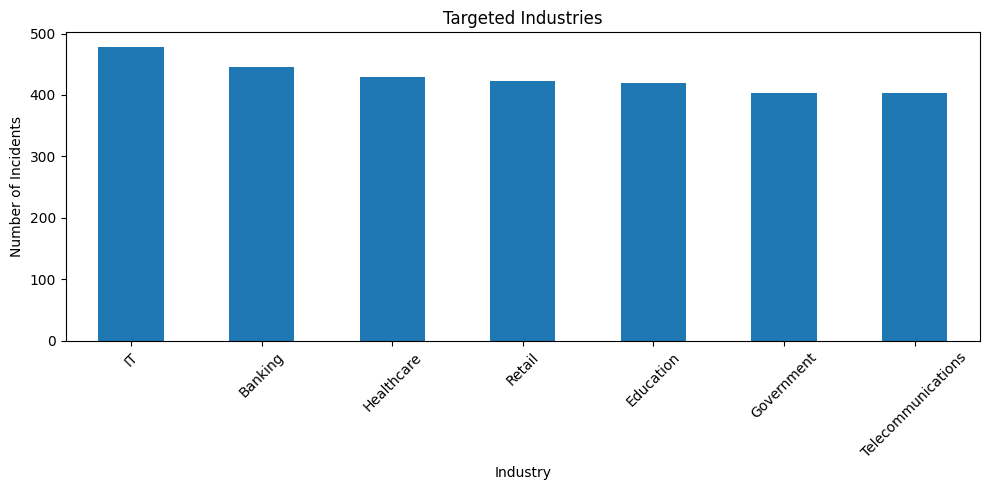

In [122]:
plt.figure(figsize=(10,5))

industry_counts.plot(kind='bar')

plt.title('Targeted Industries')
plt.xlabel('Industry')
plt.ylabel('Number of Incidents')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## Analysis & Interpretation

The IT industry experienced the highest number of cybersecurity incidents (478), making it the most targeted sector in the dataset. Banking and Healthcare also reported a high number of attacks, reflecting the value of financial, operational, and personal data maintained by these industries. This highlights the need for strong cybersecurity measures in data-intensive sectors.

# 5. Financial Loss Analysis

In [123]:
loss_by_attack = df.groupby('Attack Type')['Financial Loss (in Million $)'].sum()

loss_by_attack

,Financial Loss (in Million $)
Attack Type,
DDoS,27630.92
Malware,23967.95
Man-in-the-Middle,23550.87
Phishing,26693.29
Ransomware,24479.32
SQL Injection,25156.56


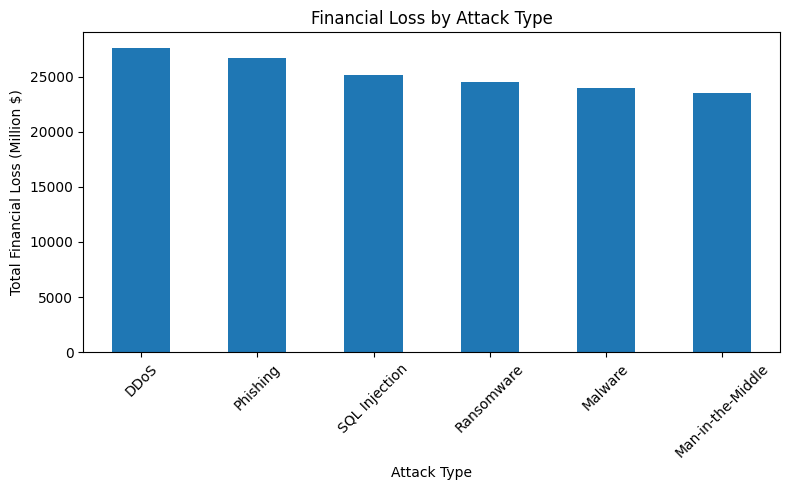

In [124]:
plt.figure(figsize=(8,5))

loss_by_attack.sort_values(ascending=False).plot(kind='bar')

plt.title('Financial Loss by Attack Type')
plt.xlabel('Attack Type')
plt.ylabel('Total Financial Loss (Million $)')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## Analysis & Interpretation

The financial loss analysis shows that different attack types can have varying economic impacts. While some attack categories occur more frequently, others may result in greater financial losses per incident. This demonstrates that organizations must evaluate cyber threats based on both frequency and potential financial damage when planning security investments.

# 6. Trend Analysis

In [125]:
attacks_by_year = df.groupby('Year').size()

attacks_by_year

,0
Year,
2015,277
2016,285
2017,319
2018,310
2019,263
2020,315
2021,299
2022,318
2023,315


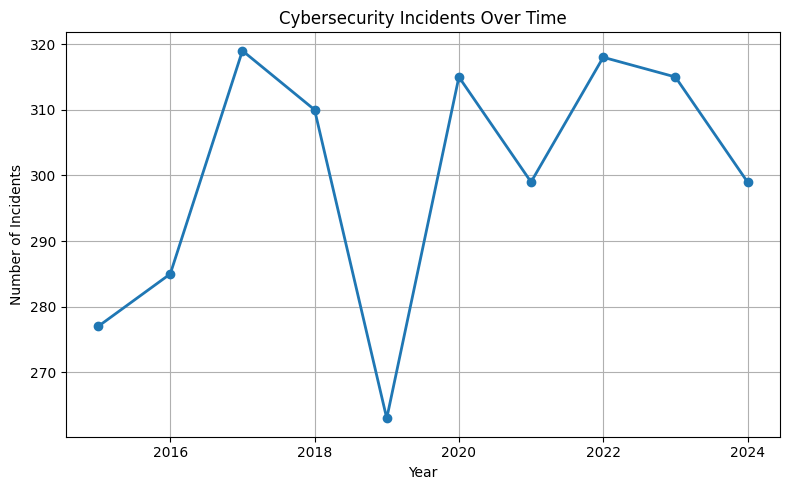

In [126]:
plt.figure(figsize=(8,5))

attacks_by_year.sort_index().plot(
    kind='line',
    marker='o',
    linewidth=2
)

plt.title('Cybersecurity Incidents Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Incidents')
plt.grid(True)

plt.tight_layout()
plt.show()

## Analysis & Interpretation

Cybersecurity incidents were recorded consistently throughout the analyzed period, demonstrating the persistent nature of cyber threats. Variations in incident frequency across years indicate changing threat landscapes and evolving attack techniques. The trend highlights the importance of continuous monitoring and proactive security strategies.

# 7. Key Findings

1. DDoS attacks were the most common cyber attack type with 531 recorded incidents.

2. The United Kingdom recorded the highest number of cybersecurity incidents among the countries analyzed.

3. The IT industry was the most targeted sector, followed by Banking and Healthcare.

4. Different attack categories caused significant financial losses, highlighting the economic impact of cyber threats.

5. Cybersecurity incidents were observed across multiple years, demonstrating the persistent nature of cyber risks.

# 8. Conclusion

This project analyzed 3,000 cybersecurity incidents using Python, Pandas, and Matplotlib to identify patterns in cyber attacks, affected industries, countries, and financial impacts.

The analysis revealed that DDoS and Phishing attacks were among the most common threats, the IT sector was the most targeted industry, and cybersecurity incidents were distributed across multiple countries and years. These findings demonstrate how data analysis can be used to better understand cybersecurity trends and support informed security decision-making.

Through this project, practical skills in data cleaning, exploratory data analysis, data visualization, and cybersecurity data interpretation were developed.